#  House Price Prediction using Linear & Lasso Regression

###  Author: Lokesh Kumar Swami  
###  Goal: Predict house prices and compare model performance

---

##  Problem Statement
The objective of this project is to build a machine learning model to predict house prices based on 
  various features and compare the performance of Linear Regression and Lasso Regression.

---

# Dataset Description 
---
The dataset consists of input features (X) and target variable (y). The features represent independent variables, and the target variable represents the output to be predicted.

X: Input features
y: Target variable

---

# Import Libraries use for lassoCv and linear regression model  

In [87]:
import pandas as pd
from sklearn.linear_model import LinearRegression,LassoCV
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# load dataset

In [88]:
house_data=pd.read_csv('HousePricePrediction.csv')
print(house_data.head())

print(f'number of rows in data_set={house_data.shape[0]}')
house_data.isnull().sum()

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  
number of rows in data_set=2919


Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

# preprocessing and feature engineering

##  Handling Missing Values & Data Splitting

In this step, we handle missing values and prepare the dataset for model training.

###  Key Observations:
- The **SalePrice** column contains approximately **50% missing values**
- Since SalePrice is the **target variable**, removing these rows would lead to significant data loss

---

###  Strategy Used:

#### 1️.Separate Known and Unknown Data
- Rows where **SalePrice is available** → used for training (**Known Data**)  
- Rows where **SalePrice is missing** → stored separately (**Unknown Data**)  

- This ensures we retain all useful information for future predictions.

---

#### 2️.Remove Missing Values (Except Target)
- For the **known dataset**, rows with missing values in other features are removed
- This helps improve model accuracy and avoids errors during training


In [89]:
#split data into input i.e is X and output i.e y
known_data=house_data[house_data['SalePrice'].notnull()]
X=known_data.drop(columns=['SalePrice'])
y=known_data['SalePrice']


X=X.dropna()

X=pd.get_dummies(X,columns=['MSZoning','LotConfig','BldgType','Exterior1st'],drop_first=True,dtype=int)

X.head()


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0,60,8450,5,2003,2003,0.0,856.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,20,9600,8,1976,1976,0.0,1262.0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2,60,11250,5,2001,2002,0.0,920.0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,70,9550,5,1915,1970,0.0,756.0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,4,60,14260,5,2000,2000,0.0,1145.0,0,0,...,0,0,0,0,0,0,0,1,0,0


# Train-Test Split
The dataset is divided into training and testing sets to evaluate the model on unseen data


In [90]:
x_train,x_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    shuffle=True
   )

# Linear Regression Model Building
In this step, a Linear Regression model is used to learn the relationship between input features and the target variable. The model is trained using the training dataset.


In [91]:
linear_model=LinearRegression()

linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Linear Regression Model Evaluation
The performance of the model is evaluated using R² (R-squared) and Adjusted R² metrics. These metrics help in understanding how well the model explains the variance in the target variable

In [92]:
r2=r2_score(y_test,y_pred)

n= x_test.shape[0]  #no.of rows in dataset
p=x_test.shape[1]    # no. of columns

adjust_r2=1-((1-r2)*(n-1)/(n-p-1)) #adjusted r2 for better  model performance check
print(f'the value of adjusted r^2={adjust_r2}')

the value of adjusted r^2=0.5676620390831404


#  Linear Regression Visualization
The relationship between actual and predicted values is visualized using a scatter plot. A reference line is added to represent perfect predictions.

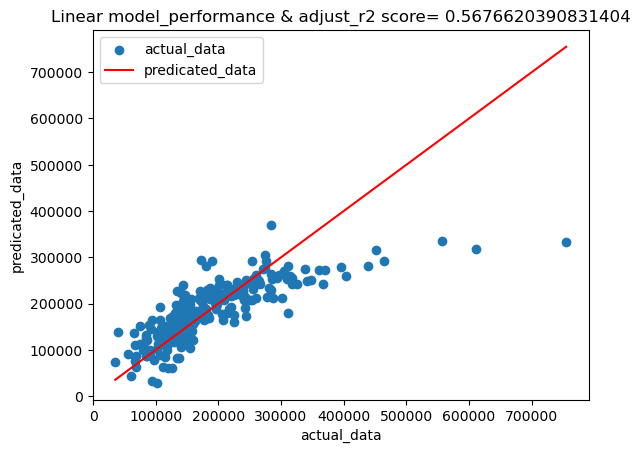

In [93]:
plt.scatter(y_test,y_pred,label='actual_data',marker='o')
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],
        color='red',label='predicated_data')
plt.xlabel('actual_data')
plt.ylabel('predicated_data')
plt.title('Linear model_performance & adjust_r2 score= 0.5676620390831404')
plt.legend()

# Lasso Regression Model Building
In this step, we use Lasso Cross-Validation (LassoCV) to automatically determine the optimal value of the regularization parameter (alpha).

- Key Steps:
1.Alpha Range Creation
  - A range of alpha values is generated using logspace
  - Values are spread logarithmically from 0.0001 to 100
 : This helps in testing both small and large regularization strengths

2.LassoCV Model Initialization
- cv=5 → Performs 5-fold cross-validation
- max_iter=1000 → Ensures proper convergence
- random_state=42 → Ensures reproducibility

3.Model Training
- The model is trained using x_train and y_train
- Cross-validation internally selects the best alpha

4.Prediction
- The trained model is used to predict values on x_test
 Results are stored in y_pred

### Benefit:
- Automatically selects the best alpha
- Prevents overfitting and improves model generalization

In [94]:
alphas = np.logspace(-4, 2, 50)

lasso_cv_model=LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(x_train,y_train)

y_pred=lasso_cv_model.predict(x_test)

# Lasso Regression Model Evaluation
The performance of the model is evaluated using R² (R-squared) and Adjusted R² metrics. These metrics help in understanding how well the model explains the variance in the target variable

In [95]:
r2=r2_score(y_test,y_pred)

n= x_test.shape[0]  #no.of rows in dataset
p=x_test.shape[1]    # no. of columns

adjust_r2=1-((1-r2)*(n-1)/(n-p-1)) #adjusted r2 for better  model performance check
print(f'the value of adjusted r^2={adjust_r2}')

the value of adjusted r^2=0.5676620390831404


# Feature Importance Visualization
- A horizontal bar chart is used to visualize feature importance based on model coefficients
- figsize ensures the plot is clear and readable
- invert_yaxis() is used to display the most important features at the top
- This improves interpretability and presentation quality

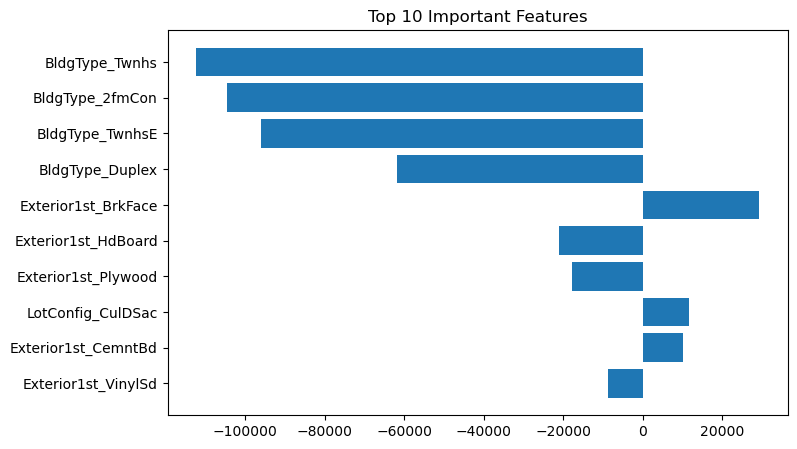

<Figure size 640x480 with 0 Axes>

In [104]:
coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lasso_cv_model.coef_
})

coef_df = coef_df.sort_values(by="Coefficient", key=abs, ascending=False)

top_features = coef_df.head(10)

plt.figure(figsize=(8,5))  #size of graph canvas
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()     #gca -get current axis
                        #reverses the Y-axis order to show first feature on top
plt.show()

plt.savefig("feature_importance.png")


# Conclusion
---
In this project, we developed a House Price Prediction model using both Linear Regression and Lasso Regression techniques.

After training and evaluating both models, it was observed that:
- Both Linear Regression and Lasso Regression produced almost the same Adjusted  R² score i.e 0.5676620390831404
- This indicates that both models have similar predictive performance on the given dataset
- Lasso Regression reduced 11 out of 34 features, simplifying the model

---
---
© Linear Regression
- Uses all features without any penalty
- Captures maximum information from the dataset
- More prone to overfitting if irrelevant features exist

© Lasso Regression
- Applies L1 regularization to penalize coefficients
-Automatically removes less important features (11 features eliminated)
- Produces a simpler and more interpretable model
---

--- 
### Further improvements can be made by using more advanced models or additional features.
---